In [1]:
import pandas as pd

data = pd.read_csv("aerosync_modeling_dataset.csv")

print("Dataset shape:", data.shape)
print("Missing values:", data.isna().sum().sum())
print("Duplicate rows:", data.duplicated().sum())

print("\nTarget distribution:")
print(data["delay_occurred"].value_counts())

data.head()

Dataset shape: (996, 15)
Missing values: 0
Duplicate rows: 0

Target distribution:
delay_occurred
0    647
1    349
Name: count, dtype: int64


,flight_id,scheduled_departure_hour,planned_capacity,passenger_count,load_factor_percent,baggage_count,total_baggage_weight_kg,average_baggage_weight_kg,staff_required,staff_available,staff_availability_pct,baggage_progress_pct,unresolved_incidents,time_remaining_minutes,delay_occurred
0,UK-633,15,307,271,88.302181,4,96.303414,24.075853,12,10,83.33,51,0,25,1
1,BA-6017,7,195,169,86.916412,5,86.829599,17.365920,9,6,66.67,60,3,103,0
2,BA-7303,13,171,141,82.792073,2,28.531802,14.265901,10,4,40.00,42,1,71,1
3,KL-7243,15,327,288,88.100542,3,59.585513,19.861838,12,8,66.67,81,0,22,1
4,SG-1280,19,180,178,98.947375,4,46.628814,11.657203,8,7,87.50,80,1,100,0


In [2]:
# Features used by the Decision Tree
feature_columns = [
    "scheduled_departure_hour",
    "load_factor_percent",
    "staff_required",
    "staff_availability_pct",
    "baggage_progress_pct",
    "unresolved_incidents",
    "time_remaining_minutes"
]

X = data[feature_columns]
y = data["delay_occurred"]

print("Features:")
print(X.columns.tolist())

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
['scheduled_departure_hour', 'load_factor_percent', 'staff_required', 'staff_availability_pct', 'baggage_progress_pct', 'unresolved_incidents', 'time_remaining_minutes']

Feature shape: (996, 7)
Target shape: (996,)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training features: (796, 7)
Testing features: (200, 7)

Training target:
delay_occurred
0    517
1    279
Name: count, dtype: int64

Testing target:
delay_occurred
0    130
1     70
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier

# Training data only
X_train_selected = data.loc[X_train.index, feature_columns]

all_feature_columns = [
    "scheduled_departure_hour",
    "load_factor_percent",
    "planned_capacity",
    "passenger_count",
    "baggage_count",
    "total_baggage_weight_kg",
    "average_baggage_weight_kg",
    "staff_required",
    "staff_available",
    "staff_availability_pct",
    "baggage_progress_pct",
    "unresolved_incidents",
    "time_remaining_minutes"
]

X_train_all = data.loc[X_train.index, all_feature_columns]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

comparison_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=20,
    random_state=42
)

selected_scores = cross_val_score(
    comparison_model,
    X_train_selected,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

all_scores = cross_val_score(
    comparison_model,
    X_train_all,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("Feature Set Comparison (Training Data Only)")
print("---------------------------------------------")
print(
    f"Selected 7 features: "
    f"{selected_scores.mean():.3f} ± {selected_scores.std():.3f}"
)

print(
    f"All 13 features: "
    f"{all_scores.mean():.3f} ± {all_scores.std():.3f}"
)

Feature Set Comparison (Training Data Only)
---------------------------------------------
Selected 7 features: 0.807 ± 0.026
All 13 features: 0.801 ± 0.026


In [5]:
from sklearn.metrics import accuracy_score

baseline_predictions = [0] * len(y_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print("Baseline accuracy:", round(baseline_accuracy, 4))

Baseline accuracy: 0.65


In [6]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [7]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

y_pred = dt_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", round(accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.705

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.76      0.77       130
           1       0.58      0.60      0.59        70

    accuracy                           0.70       200
   macro avg       0.68      0.68      0.68       200
weighted avg       0.71      0.70      0.71       200


Confusion Matrix:
[[99 31]
 [28 42]]


In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "criterion": ["gini", "entropy"]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(round(grid_search.best_score_, 4))

Best parameters:
{'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 20}

Best cross-validation ROC-AUC:
0.7906


In [9]:
depth_results = []

for depth in [2, 3, 4, 5, 6, 8, 10, None]:
    model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        min_samples_leaf=20,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc"
    )

    depth_results.append({
        "Max Depth": depth if depth is not None else "None",
        "Mean CV ROC-AUC": round(scores.mean(), 4),
        "Std": round(scores.std(), 4)
    })

depth_comparison = pd.DataFrame(depth_results)

print(depth_comparison.to_string(index=False))

Max Depth  Mean CV ROC-AUC    Std
        2           0.7740 0.0088
        3           0.7896 0.0131
        4           0.7875 0.0202
        5           0.7902 0.0295
        6           0.7904 0.0290
        8           0.7906 0.0290
       10           0.7906 0.0290
     None           0.7906 0.0290


In [10]:
FINAL_PARAMS = {
    "criterion": "gini",
    "max_depth": 3,
    "min_samples_leaf": 20
}

tuned_dt = DecisionTreeClassifier(
    **FINAL_PARAMS,
    random_state=42
)

tuned_dt.fit(X_train, y_train)

print(
    "Depth:", tuned_dt.get_depth(),
    " Leaves:", tuned_dt.get_n_leaves()
)

Depth: 3  Leaves: 8


In [11]:
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(
    y_train,
    tuned_dt.predict(X_train)
)

test_acc = accuracy_score(
    y_test,
    tuned_dt.predict(X_test)
)

print("Training accuracy:", round(train_acc, 4))
print("Test accuracy:", round(test_acc, 4))

Training accuracy: 0.7864
Test accuracy: 0.755


In [12]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

y_pred_tuned = tuned_dt.predict(X_test)
y_prob_tuned = tuned_dt.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred_tuned)
roc_auc = roc_auc_score(y_test, y_prob_tuned)

print("Test Accuracy:", round(accuracy, 4))
print("Test ROC-AUC:", round(roc_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

Test Accuracy: 0.755
Test ROC-AUC: 0.7946

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       130
           1       0.64      0.67      0.66        70

    accuracy                           0.76       200
   macro avg       0.73      0.74      0.73       200
weighted avg       0.76      0.76      0.76       200


Confusion Matrix:
[[104  26]
 [ 23  47]]


In [13]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": tuned_dt.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.to_string(index=False))

                 Feature  Importance
  time_remaining_minutes    0.369902
    baggage_progress_pct    0.355325
  staff_availability_pct    0.274774
          staff_required    0.000000
     load_factor_percent    0.000000
scheduled_departure_hour    0.000000
    unresolved_incidents    0.000000


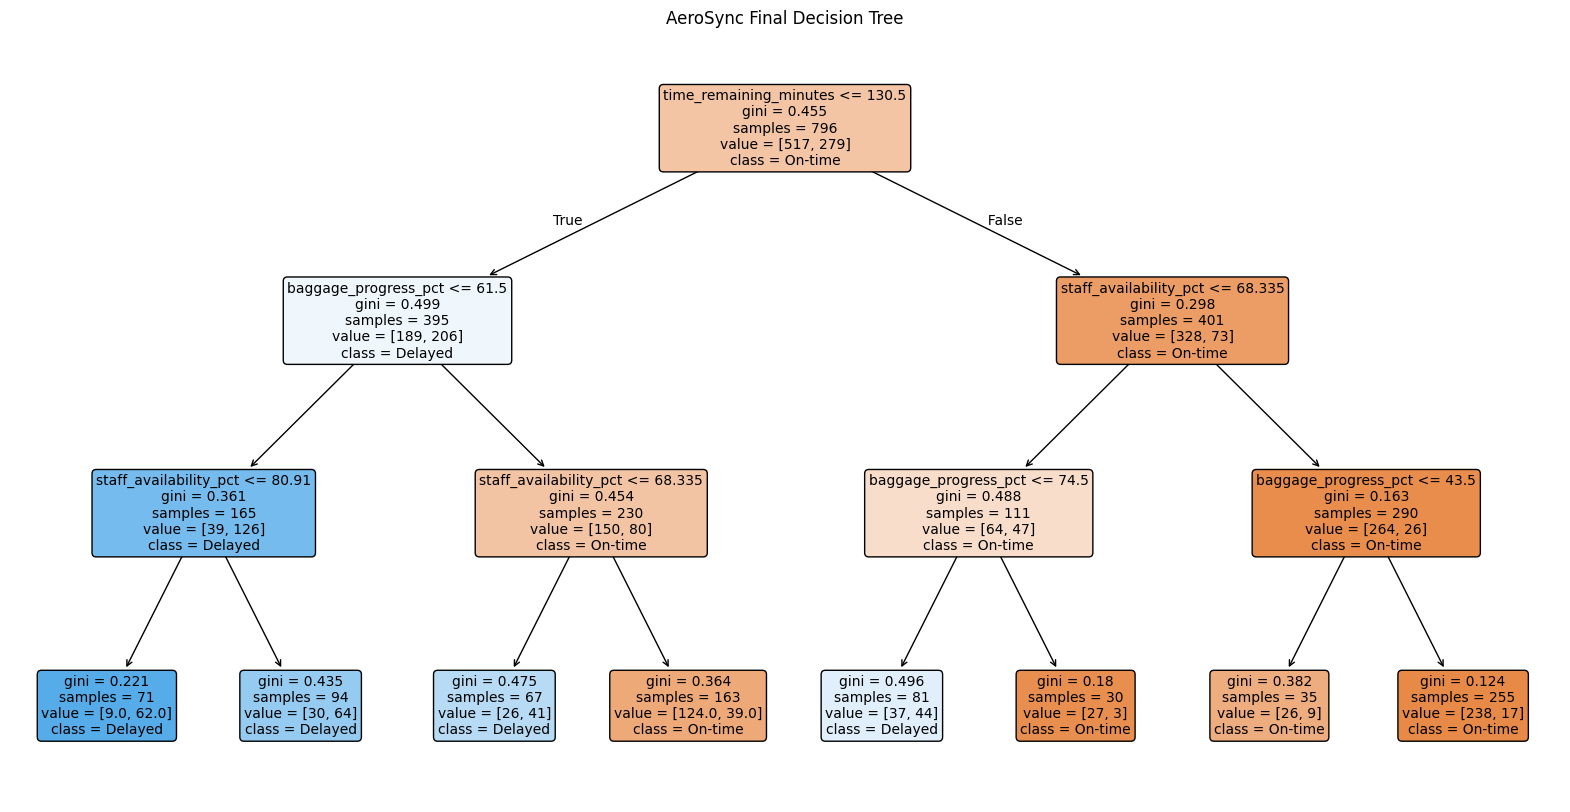

In [14]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    tuned_dt,
    feature_names=X.columns,
    class_names=["On-time", "Delayed"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("AeroSync Final Decision Tree")
plt.show()

In [15]:
from sklearn.tree import export_text

tree_rules = export_text(
    tuned_dt,
    feature_names=list(X.columns)
)

print(tree_rules)

|--- time_remaining_minutes <= 130.50
|   |--- baggage_progress_pct <= 61.50
|   |   |--- staff_availability_pct <= 80.91
|   |   |   |--- class: 1
|   |   |--- staff_availability_pct >  80.91
|   |   |   |--- class: 1
|   |--- baggage_progress_pct >  61.50
|   |   |--- staff_availability_pct <= 68.33
|   |   |   |--- class: 1
|   |   |--- staff_availability_pct >  68.33
|   |   |   |--- class: 0
|--- time_remaining_minutes >  130.50
|   |--- staff_availability_pct <= 68.33
|   |   |--- baggage_progress_pct <= 74.50
|   |   |   |--- class: 1
|   |   |--- baggage_progress_pct >  74.50
|   |   |   |--- class: 0
|   |--- staff_availability_pct >  68.33
|   |   |--- baggage_progress_pct <= 43.50
|   |   |   |--- class: 0
|   |   |--- baggage_progress_pct >  43.50
|   |   |   |--- class: 0



In [16]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_probabilities = cross_val_predict(
    tuned_dt,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)[:, 1]

thresholds = np.arange(0.20, 0.71, 0.05)

threshold_results = []

for threshold in thresholds:
    predictions = (cv_probabilities >= threshold).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": round(
            precision_score(y_train, predictions, zero_division=0), 2
        ),
        "Recall": round(
            recall_score(y_train, predictions, zero_division=0), 2
        ),
        "F1": round(
            f1_score(y_train, predictions, zero_division=0), 2
        )
    })

threshold_results_df = pd.DataFrame(threshold_results)

print(threshold_results_df.to_string(index=False))

 Threshold  Precision  Recall   F1
      0.20       0.51    0.86 0.64
      0.25       0.58    0.78 0.67
      0.30       0.64    0.75 0.69
      0.35       0.64    0.75 0.69
      0.40       0.64    0.75 0.69
      0.45       0.64    0.75 0.69
      0.50       0.64    0.71 0.67
      0.55       0.67    0.59 0.63
      0.60       0.70    0.47 0.56
      0.65       0.75    0.35 0.48
      0.70       0.77    0.23 0.35


In [17]:
# 0.30 is chosen from the plateau of best cross-validated F1.
# The lower threshold favours catching potential delays.
final_threshold = 0.30

print("Final classification threshold:", final_threshold)

Final classification threshold: 0.3


In [18]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Get probabilities for the untouched test set
y_prob_final = tuned_dt.predict_proba(X_test)[:, 1]

# Apply the selected threshold
y_pred_final = (y_prob_final >= final_threshold).astype(int)

print("Final Test Evaluation")
print("---------------------")

print("Threshold:", final_threshold)
print("Accuracy:", round(accuracy_score(y_test, y_pred_final), 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=["On-time", "Delayed"]
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

Final Test Evaluation
---------------------
Threshold: 0.3
Accuracy: 0.755

Classification Report:
              precision    recall  f1-score   support

     On-time       0.82      0.80      0.81       130
     Delayed       0.64      0.67      0.66        70

    accuracy                           0.76       200
   macro avg       0.73      0.74      0.73       200
weighted avg       0.76      0.76      0.76       200

Confusion Matrix:
[[104  26]
 [ 23  47]]


In [19]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Bootstrap confidence intervals for final test metrics
rng = np.random.default_rng(42)
n_bootstrap = 5000

metrics = {
    "Accuracy": accuracy_score,
    "Precision": lambda y_true, y_pred: precision_score(
        y_true, y_pred, zero_division=0
    ),
    "Recall": lambda y_true, y_pred: recall_score(
        y_true, y_pred, zero_division=0
    ),
    "F1": lambda y_true, y_pred: f1_score(
        y_true, y_pred, zero_division=0
    )
}

print("Bootstrap 95% Confidence Intervals")
print("-----------------------------------")

for metric_name, metric_function in metrics.items():
    scores = []

    for _ in range(n_bootstrap):
        indices = rng.integers(
            0,
            len(y_test),
            size=len(y_test)
        )

        y_true_sample = y_test.iloc[indices]
        y_pred_sample = y_pred_final[indices]

        scores.append(
            metric_function(
                y_true_sample,
                y_pred_sample
            )
        )

    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)
    estimate = metric_function(y_test, y_pred_final)

    print(
        f"{metric_name}: "
        f"{estimate:.3f} "
        f"(95% CI: {lower:.3f} - {upper:.3f})"
    )

Bootstrap 95% Confidence Intervals
-----------------------------------
Accuracy: 0.755 (95% CI: 0.695 - 0.815)
Precision: 0.644 (95% CI: 0.537 - 0.750)
Recall: 0.671 (95% CI: 0.559 - 0.783)
F1: 0.657 (95% CI: 0.559 - 0.739)


In [20]:
# AeroSync hybrid risk indicator: Decision Tree probability + prototype operational rules
#
# The rule thresholds below are prototype assumptions, fixed before evaluation.
# They are not official Kenya Airways operational thresholds.

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ---- Operational rules (defined once, used by both the baseline and the hybrid) ----
def count_rule_triggers(row):
    triggers = 0

    # R1: Limited time and insufficient baggage progress
    if row["time_remaining_minutes"] <= 60 and row["baggage_progress_pct"] < 70:
        triggers += 1

    # R2: Moderate time pressure and very low baggage progress
    if row["time_remaining_minutes"] <= 90 and row["baggage_progress_pct"] < 50:
        triggers += 1

    # R3: Staff shortage under time pressure
    if row["staff_availability_pct"] < 70 and row["time_remaining_minutes"] <= 120:
        triggers += 1

    # R4: Multiple unresolved incidents near departure
    if row["unresolved_incidents"] >= 2 and row["time_remaining_minutes"] <= 120:
        triggers += 1

    return triggers


# ---- Hybrid risk level ----
def hybrid_risk(delay_probability, rule_triggers, threshold):
    if delay_probability >= threshold and rule_triggers >= 2:
        return "High"
    elif delay_probability >= threshold or rule_triggers >= 1:
        return "Medium"
    else:
        return "Low"


# ---- Apply to the test set ----
hybrid_results = pd.DataFrame({
    "delay_probability": tuned_dt.predict_proba(X_test)[:, 1],
    "rule_triggers": X_test.apply(count_rule_triggers, axis=1).values,
    "actual_delay": y_test.values
}, index=X_test.index)

hybrid_results["risk_level"] = [
    hybrid_risk(p, r, final_threshold)
    for p, r in zip(
        hybrid_results["delay_probability"],
        hybrid_results["rule_triggers"]
    )
]

# ---- 1. Does the risk level track actual delays? ----
levels = ["High", "Medium", "Low"]

risk_summary = (
    hybrid_results
    .groupby("risk_level")["actual_delay"]
    .agg(["count", "mean"])
    .reindex(levels)
)
risk_summary.columns = ["Flights", "Actual delay rate (%)"]
risk_summary["Actual delay rate (%)"] = (
    risk_summary["Actual delay rate (%)"] * 100
).round(1)

print("Hybrid Risk Indicator (test set)")
print("--------------------------------")
print(risk_summary)

# ---- 2. Rules only vs tree only vs hybrid ----
pred_rules = (hybrid_results["rule_triggers"] >= 1).astype(int)
pred_tree = (hybrid_results["delay_probability"] >= final_threshold).astype(int)
pred_hybrid = (hybrid_results["risk_level"] != "Low").astype(int)   # Medium or High

comparison_rows = []
for name, pred in [
    ("Rules only", pred_rules),
    ("Decision Tree only", pred_tree),
    ("Hybrid (Medium or High)", pred_hybrid)
]:
    comparison_rows.append({
        "Approach": name,
        "Accuracy": round(accuracy_score(y_test, pred), 3),
        "Precision": round(precision_score(y_test, pred, zero_division=0), 3),
        "Recall": round(recall_score(y_test, pred, zero_division=0), 3),
        "F1": round(f1_score(y_test, pred, zero_division=0), 3),
        "Flights flagged (%)": round(pred.mean() * 100, 1)
    })

print("\nComparison on the test set")
print("--------------------------")
print(pd.DataFrame(comparison_rows).to_string(index=False))

# ---- 3. Detail for the hybrid ----
print("\nHybrid (Medium or High) classification report:")
print(
    classification_report(
        y_test,
        pred_hybrid,
        target_names=["On-time", "Delayed"]
    )
)

print("Confusion matrix:")
print(confusion_matrix(y_test, pred_hybrid))

print("\nSample results:")
print(hybrid_results.head(10))

Hybrid Risk Indicator (test set)
--------------------------------
            Flights  Actual delay rate (%)
risk_level                                
High             16                   87.5
Medium           71                   56.3
Low             113                   14.2

Comparison on the test set
--------------------------
               Approach  Accuracy  Precision  Recall    F1  Flights flagged (%)
             Rules only     0.770      0.714   0.571 0.635                 28.0
     Decision Tree only     0.755      0.644   0.671 0.657                 36.5
Hybrid (Medium or High)     0.755      0.621   0.771 0.688                 43.5

Hybrid (Medium or High) classification report:
              precision    recall  f1-score   support

     On-time       0.86      0.75      0.80       130
     Delayed       0.62      0.77      0.69        70

    accuracy                           0.76       200
   macro avg       0.74      0.76      0.74       200
weighted avg       0.78 

In [21]:
scenarios = pd.DataFrame([
    {
        "Scenario": "High-risk operation",
        "scheduled_departure_hour": 14,
        "load_factor_percent": 95,
        "staff_required": 20,
        "staff_availability_pct": 50,
        "baggage_progress_pct": 40,
        "unresolved_incidents": 3,
        "time_remaining_minutes": 45
    },
    {
        "Scenario": "Moderate-risk operation",
        "scheduled_departure_hour": 14,
        "load_factor_percent": 85,
        "staff_required": 18,
        "staff_availability_pct": 75,
        "baggage_progress_pct": 65,
        "unresolved_incidents": 1,
        "time_remaining_minutes": 90
    },
    {
        "Scenario": "Low-risk operation",
        "scheduled_departure_hour": 14,
        "load_factor_percent": 70,
        "staff_required": 15,
        "staff_availability_pct": 100,
        "baggage_progress_pct": 90,
        "unresolved_incidents": 0,
        "time_remaining_minutes": 180
    }
])

scenario_features = scenarios[feature_columns]

scenario_probabilities = tuned_dt.predict_proba(
    scenario_features
)[:, 1]

scenarios["Delay Probability (%)"] = (
    scenario_probabilities * 100
).round(1)

scenarios["Prediction"] = [
    "Delayed" if p >= final_threshold else "On-time"
    for p in scenario_probabilities
]

print(
    scenarios[
        [
            "Scenario",
            "Delay Probability (%)",
            "Prediction"
        ]
    ].to_string(index=False)
)

               Scenario  Delay Probability (%) Prediction
    High-risk operation                   87.3    Delayed
Moderate-risk operation                   23.9    On-time
     Low-risk operation                    6.7    On-time


In [22]:
import joblib
import sklearn

joblib.dump(
    {
        "model": tuned_dt,
        "features": feature_columns,
        "threshold": final_threshold,
        "sklearn_version": sklearn.__version__,
        "rules_description": [
            "R1: time_remaining_minutes <= 60 and baggage_progress_pct < 70",
            "R2: time_remaining_minutes <= 90 and baggage_progress_pct < 50",
            "R3: staff_availability_pct < 70 and time_remaining_minutes <= 120",
            "R4: unresolved_incidents >= 2 and time_remaining_minutes <= 120",
        ],
        "hybrid_logic": (
            "High: probability >= threshold and at least 2 rules triggered; "
            "Medium: probability >= threshold or at least 1 rule triggered; "
            "Low: otherwise"
        ),
    },
    "aerosync_decision_tree.pkl"
)

print("Final model saved successfully.")

Final model saved successfully.


In [23]:
saved = joblib.load("aerosync_decision_tree.pkl")

print("Contents:", list(saved.keys()))
print("Threshold:", saved["threshold"])
print()
for rule in saved["rules_description"]:
    print(rule)
print()
print(saved["hybrid_logic"])

Contents: ['model', 'features', 'threshold', 'sklearn_version', 'rules_description', 'hybrid_logic']
Threshold: 0.3

R1: time_remaining_minutes <= 60 and baggage_progress_pct < 70
R2: time_remaining_minutes <= 90 and baggage_progress_pct < 50
R3: staff_availability_pct < 70 and time_remaining_minutes <= 120
R4: unresolved_incidents >= 2 and time_remaining_minutes <= 120

High: probability >= threshold and at least 2 rules triggered; Medium: probability >= threshold or at least 1 rule triggered; Low: otherwise


In [24]:
import os

print("File exists:", os.path.exists("aerosync_decision_tree.pkl"))
print("File size:", os.path.getsize("aerosync_decision_tree.pkl"), "bytes")

File exists: True
File size: 3602 bytes


In [25]:
from google.colab import files
files.download("aerosync_decision_tree.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>